# IEMOCAP — каскадная аудио→видео система распознавания эмоций (4 класса, LOSO)

Реализация и оценка **каскадной** системы распознавания эмоций на IEMOCAP: аудио работает фильтром (neutral / non-neutral), видео — только для не-нейтральных эмоций. Текст / транскрипции не используются.

## Схема каскада
1. **Аудио-модель** — бинарная классификация **neutral / non-neutral**.
2. **Видео-модель** — 3-классовая (**happy / sad / angry**), применяется только к примерам, которые аудио-модель назвала **non-neutral**.
3. **Итог:** гейт сказал *neutral* → класс `neutral`; гейт сказал *non-neutral* → класс берётся от видео-модели.

## Ключевая особенность
Обе модели **предобучены на RAVDESS + CREMA-D**. Их веса используются как инициализация и **двухэтапно дообучаются** на IEMOCAP в каждом фолде (feature-extraction → fine-tuning).

## Датасет и протокол
IEMOCAP, 4 класса: **neutral, happy (∪ excited), sad, angry** (`frustrated/fear/surprise/disgust/oth/xxx` отброшены). Оценка — строгая **LOSO 5-fold**: одна сессия тест, следующая по циклу — валидация, остальные три — обучение. Метрики усредняются по 5 фолдам (± std), главная — **UA (UAR)**.

> Имя файла сохраняет префикс `e2e` по историческим причинам; архитектура — каскад, не end-to-end слияние.

## 1. Конфигурация

Пути, гиперпараметры двухэтапного обучения (§8) и параметры log-mel (из `meta.json` предобученной MelCNN). Аудио-предобработка намеренно совпадает с предобучением MelCNN, а не с §4 плана — иначе вход модели уходит из распределения, на котором настроены её веса (см. §3 и «Заметки»).

In [11]:
# === Конфигурация ===
import os, re, json, gc, pickle, random, warnings
warnings.filterwarnings('ignore')
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import librosa

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight

device = torch.device('cuda' if torch.cuda.is_available()
                       else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print('Device:', device)

# --- пути
IEMOCAP_ROOT   = '../datasets/IEMOCAP_full_release'
V3_CACHE       = Path('../datasets/iemocap_features_cache_v3')   # признаки EmotiEffNet (video_eff)
AUDIO_CACHE    = Path('../datasets/iemocap_audio_cache_v2')      # waveform 16 кГц + log-mel
AUDIO_CKPT_DIR = '../trained_models/audio_neutral_3_augmentation'
VIDEO_CKPT_DIR = '../trained_models/video_emotion_3_augmentation'
OUT_DIR        = Path('../trained_models/iemocap_e2e_multimodal')
FOLD_DIR       = OUT_DIR / 'folds'      # результаты по каждому фолду
MODEL_DIR      = OUT_DIR / 'models'     # лучшие веса обеих моделей по фолдам
for _d in (AUDIO_CACHE, OUT_DIR, FOLD_DIR, MODEL_DIR):
    _d.mkdir(parents=True, exist_ok=True)

# --- классы
LABELS_4 = ['neutral', 'happy', 'sad', 'angry']     # итоговая 4-классовая задача
LABELS_3 = ['happy', 'sad', 'angry']                # не-нейтральные, для видео-модели
RAW2IDX  = {'neu': 0, 'hap': 1, 'exc': 1, 'sad': 2, 'ang': 3}
N_CLS    = len(LABELS_4)

# --- log-mel: параметры строго из meta.json предобученной MelCNN.
# Предобработка совпадает с предобучением (audio_neutral_check_augmentation):
# только load + resample 16 кГц, без trim / pre-emphasis / peak-norm — иначе
# вход MelCNN оказывается вне распределения, на котором учились её веса.
_amETA   = json.load(open(os.path.join(AUDIO_CKPT_DIR, 'meta.json')))
SR         = _amETA['SR']            # 16000
N_MELS     = _amETA['N_MELS']        # 64
HOP        = _amETA['HOP']           # 512
MEL_MAXLEN = _amETA['MAX_LEN']       # 128 кадров — фиксированный вход MelCNN
MEL_MEAN   = _amETA['mel_mean']      # глобальная норм-статистика предобучения
MEL_STD    = _amETA['mel_std']
print(f'audio: SR={SR}  n_mels={N_MELS}  hop={HOP}  mel_len={MEL_MAXLEN}  '
      f'mean={MEL_MEAN:.2f}  std={MEL_STD:.2f}')

FEAT_EFF = 1280                      # размерность признаков EmotiEffNet

# --- двухэтапное обучение (§8)
STAGE1_EPOCHS     = 8       # этап 1 (feature extraction): только новая голова
STAGE2_MAX_EPOCHS = 50      # этап 2 (fine-tuning): максимум эпох
PATIENCE          = 15      # early stopping по val UA (этап 2)
PLATEAU_PATIENCE  = 5       # ReduceLROnPlateau
LR_HEAD_S1   = 1e-4         # этап 1: lr головы
LR_PRETRAIN  = 1e-5         # этап 2: lr предобученной части
LR_NEWHEAD   = 4e-5         # этап 2: lr новой головы
WD           = 0.01         # weight decay (AdamW)
BS           = 16           # §8.2: батч-сайз
GAMMA        = 2.0          # §8.2: focal loss
LABEL_SMOOTH = 0.1          # §8.2: label smoothing
AUG_P        = 0.5          # §6: вероятность каждой аудио-аугментации
NUM_WORKERS  = 0            # macOS/MPS/Jupyter: 0 безопаснее (на CUDA можно поднять)

# --- быстрая проверка пайплайна
QUICK_TEST = False
if QUICK_TEST:
    STAGE1_EPOCHS, STAGE2_MAX_EPOCHS, PATIENCE = 2, 3, 2

# --- §11: фиксация всех random seed
SEED = 42
def seed_everything(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
seed_everything()

SESSIONS = [f'Session{i}' for i in range(1, 6)]
# циклический val: test=S1->val=S2, ..., test=S5->val=S1
LOSO_VAL_FOR_TEST = {s: SESSIONS[(i + 1) % 5] for i, s in enumerate(SESSIONS)}
print('LOSO val mapping:', LOSO_VAL_FOR_TEST)

Device: mps
audio: SR=16000  n_mels=64  hop=512  mel_len=128  mean=-31.41  std=26.38
LOSO val mapping: {'Session1': 'Session2', 'Session2': 'Session3', 'Session3': 'Session4', 'Session4': 'Session5', 'Session5': 'Session1'}


## 2. Метаданные IEMOCAP (4 класса)

Парсим `EmoEvaluation/*.txt` всех 5 сессий. Оставляем 4 класса: `neutral, happy, sad, angry`; `excited` приклеивается к `happy`; `frustrated/fear/surprise/disgust/oth/xxx` отбрасываются. Берём только реплики, для которых уже есть видеопризнаки в кеше `iemocap_features_cache_v3`.

In [12]:
# === Метаданные IEMOCAP (4 класса) ===
EMO_LINE_RE = re.compile(r'^\[\s*([\d.]+)\s*-\s*([\d.]+)\s*\]\s+(\S+)\s+(\w+)\s+\[')

def parse_emoeval(eval_path, session):
    rows = []
    with open(eval_path, encoding='utf-8', errors='ignore') as f:
        for line in f:
            m = EMO_LINE_RE.match(line)
            if m:
                _, _, utt_id, emo = m.groups()
                rows.append({'session': session, 'utterance_id': utt_id,
                             'emotion_raw': emo})
    return rows

records = []
for s in range(1, 6):
    sess = f'Session{s}'
    eval_dir = Path(IEMOCAP_ROOT) / sess / 'dialog' / 'EmoEvaluation'
    for txt in sorted(eval_dir.glob('*.txt')):
        if not txt.name.startswith('.'):
            records.extend(parse_emoeval(txt, sess))

meta = (pd.DataFrame.from_records(records)
          .drop_duplicates('utterance_id').reset_index(drop=True))
print(f'Сырых реплик из EmoEvaluation: {len(meta)}')
print('Категории до фильтрации:', meta.emotion_raw.value_counts().to_dict())

# 4 класса: happy + excited -> happy; остальное отброшено
meta = meta[meta.emotion_raw.isin(RAW2IDX)].reset_index(drop=True)
meta['label']   = meta.emotion_raw.map(RAW2IDX)
meta['emotion'] = meta.label.map(dict(enumerate(LABELS_4)))

def v3_path(utt_id):
    return V3_CACHE / f'{utt_id}.pt'

# оставляем только реплики с готовыми видеопризнаками в кеше v3
have_v = meta.utterance_id.apply(lambda u: v3_path(u).exists())
print(f'\nРеплик 4 классов: {len(meta)} | с видеопризнаками в кеше v3: {int(have_v.sum())}')
meta = meta[have_v].reset_index(drop=True)
assert len(meta) > 0, ('кеш iemocap_features_cache_v3 пуст — сначала постройте его '
                       'ячейкой извлечения признаков в full_pipeline_iemocap.ipynb')

if QUICK_TEST:
    meta = (meta.groupby('session', group_keys=False)
                .apply(lambda d: d.sample(min(len(d), 80), random_state=SEED))
                .reset_index(drop=True))
    print(f'QUICK_TEST: subsample -> {len(meta)}')

print('\nРаспределение классов по сессиям:')
print(meta.groupby(['session', 'emotion']).size().unstack(fill_value=0))

Сырых реплик из EmoEvaluation: 10039
Категории до фильтрации: {'xxx': 2507, 'fru': 1849, 'neu': 1708, 'ang': 1103, 'sad': 1084, 'exc': 1041, 'hap': 595, 'sur': 107, 'fea': 40, 'oth': 3, 'dis': 2}

Реплик 4 классов: 5531 | с видеопризнаками в кеше v3: 5531

Распределение классов по сессиям:
emotion   angry  happy  neutral  sad
session                             
Session1    229    278      384  194
Session2    137    327      362  197
Session3    240    286      320  305
Session4    327    303      258  143
Session5    170    442      384  245


## 3. Аудио-утилиты: предобработка, log-mel и аугментации (§6)

**Предобработка.** Аудио загружается и ресемплится в 16 кГц — и **больше ничего**: ни тримминга, ни pre-emphasis, ни peak-нормализации. Это осознанное отклонение от §4 плана: предобученная `MelCNN` (RAVDESS+CREMA-D) училась именно на таком входе, а trim/pre-emphasis меняют спектральный наклон и уводят вход модели из её распределения — предобученная инициализация (§7) теряет смысл. Приоритет отдан работоспособности предобученных весов.

**log-mel** для MelCNN: 64 mel-канала, hop 512, `power_to_db(ref=np.max)`, нормировка `(logmel − mel_mean) / mel_std` глобальными статистиками предобучения — всё в точности как в `audio_neutral_check_augmentation.ipynb`. Время приводится к 128 кадрам (фиксированный вход MelCNN): короткие реплики дополняются нулями, длинные **линейно интерполируются** по оси времени — вся реплика сжимается в окно, поздний эмоциональный контент не теряется (раньше бралась только первая ≈ 4.1 с).

**§6 Аугментации** (только при обучении, каждая независимо с вероятностью `AUG_P`): гауссовский шум 0.001–0.015; сдвиг во времени ±1 с без заворачивания; time-stretch 0.9–1.1; сдвиг высоты тона ±2 полутона. Random gain и инверсия полярности из §6 плана на log-mel с `ref=np.max` **не влияют вообще** (она инвариантна к общему масштабу, а магнитудная mel — к знаку) — поэтому заменены на сдвиг и time-stretch, чтобы реально работали все четыре аугментации.

In [13]:
# === Аудио: предобработка, log-mel, аугментации §6 ===
def wav_path(session, utt_id):
    """Путь к sentence-wav: Session*/sentences/wav/{dialog}/{utt}.wav."""
    dialog = utt_id.rsplit('_', 1)[0]
    return Path(IEMOCAP_ROOT) / session / 'sentences' / 'wav' / dialog / f'{utt_id}.wav'

def preprocess_audio(path):
    """Загрузка raw waveform 16 кГц — как при предобучении MelCNN
    (audio_neutral_check_augmentation: load + resample, без trim/pre-emphasis/peak-norm)."""
    y, _ = librosa.load(path, sr=SR, mono=True)
    return y.astype(np.float32)

def wave_to_logmel(y):
    """Waveform -> нормированная log-mel (N_MELS, MEL_MAXLEN) — вход MelCNN.
    Время приводится к 128 кадрам: коротко -> zero-pad, длинно -> линейная
    интерполяция (вся реплика сжимается в окно, поздний контент не теряется)."""
    if y is None or len(y) < 2:
        y = np.zeros(HOP * 8, dtype=np.float32)
    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS, hop_length=HOP)
    lm  = librosa.power_to_db(mel, ref=np.max)
    T = lm.shape[1]
    if T < MEL_MAXLEN:
        lm = np.pad(lm, ((0, 0), (0, MEL_MAXLEN - T)))
    elif T > MEL_MAXLEN:
        lm = F.interpolate(torch.tensor(lm, dtype=torch.float32)[None],
                           size=MEL_MAXLEN, mode='linear',
                           align_corners=False)[0].numpy()
    lm = (lm - MEL_MEAN) / MEL_STD
    return torch.tensor(lm, dtype=torch.float32)

def augment_waveform(y):
    """§6: аудио-аугментации только при обучении. Каждая независимо с вероятностью AUG_P.
    Все четыре реально меняют log-mel с ref=np.max — random gain и инверсия
    полярности (no-op для такой log-mel) заменены на сдвиг и time-stretch."""
    y = y.copy().astype(np.float32)
    if random.random() < AUG_P:                           # гауссовский шум 0.001..0.015
        y = y + np.random.randn(len(y)).astype(np.float32) * random.uniform(0.001, 0.015)
    if random.random() < AUG_P and len(y) > 4:            # сдвиг во времени ±1 с, без заворачивания
        s = int(np.clip(random.uniform(-1.0, 1.0) * SR, -len(y) // 2, len(y) // 2))
        if s > 0:
            y = np.concatenate([np.zeros(s, np.float32), y[:-s]])
        elif s < 0:
            y = np.concatenate([y[-s:], np.zeros(-s, np.float32)])
    if random.random() < AUG_P and len(y) > 2048:         # time-stretch 0.9..1.1
        y = librosa.effects.time_stretch(y, rate=random.uniform(0.9, 1.1))
    if random.random() < AUG_P and len(y) > 2048:         # pitch shift ±2 полутона
        y = librosa.effects.pitch_shift(y, sr=SR, n_steps=random.uniform(-2.0, 2.0))
    return y.astype(np.float32)

print('Аудио-утилиты готовы: preprocess_audio, wave_to_logmel, augment_waveform (§6).')

Аудио-утилиты готовы: preprocess_audio, wave_to_logmel, augment_waveform (§6).


## 4. Кеш аудио

Один раз прогоняем загрузку + ресемпл 16 кГц по всем репликам и сохраняем в `datasets/iemocap_audio_cache_v2/{utt}.pt`: волновую форму нативной длины (для аугментаций §6 на лету) и «чистую» log-mel (для валидации/теста без пересчёта). Сборка идемпотентна — повторный запуск пропускает готовые файлы. Размер ≈ 2 ГБ.

> Суффикс `v2`: кеш `v1` хранил §4-предобработанные (trim/pre-emphasis/8 с) волны и log-mel и потому несовместим — его нужно перестроить заново.

In [14]:
# === Сборка аудио-кеша (§4) ===
def build_audio_cache():
    missing = []
    for r in tqdm(list(meta.itertuples()), desc='audio cache'):
        out = AUDIO_CACHE / f'{r.utterance_id}.pt'
        if out.exists():
            continue
        wp = wav_path(r.session, r.utterance_id)
        if not wp.exists():
            missing.append(r.utterance_id)
            continue
        y = preprocess_audio(wp)
        torch.save({'wave': torch.from_numpy(y),
                    'logmel': wave_to_logmel(y)}, out)
    return missing

missing = build_audio_cache()
if missing:
    print(f'ВНИМАНИЕ: не найдено wav для {len(missing)} реплик (пример: {missing[:3]})')

# финальный meta: реплики с готовым и видео-, и аудио-кешем
have_a = meta.utterance_id.apply(lambda u: (AUDIO_CACHE / f'{u}.pt').exists())
meta = meta[have_a].reset_index(drop=True)
print(f'\nИтоговый meta (видео + аудио кеш): {len(meta)} реплик')
print(meta.groupby(['session', 'emotion']).size().unstack(fill_value=0))

audio cache:   0%|          | 0/5531 [00:00<?, ?it/s]


Итоговый meta (видео + аудио кеш): 5531 реплик
emotion   angry  happy  neutral  sad
session                             
Session1    229    278      384  194
Session2    137    327      362  197
Session3    240    286      320  305
Session4    327    303      258  143
Session5    170    442      384  245


## 5. Датасеты

Три датасета под каскад:
- `GateDS` — для аудио-модели: log-mel → **бинарная** метка (0 neutral / 1 non-neutral). При обучении применяет аугментации §6 и пересчитывает log-mel; на валидации берёт «чистую» log-mel из кеша.
- `VideoDS` — для видео-модели: признаки EmotiEffNet → **3-классовая** метка (0 happy / 1 sad / 2 angry). На вход подаётся датафрейм, уже отфильтрованный по non-neutral (§11 — нейтральные в обучение видео-модели не попадают).
- `CascadeEvalDS` — для каскадной оценки: `(log-mel, video_eff, 4-классовая метка)`.

> Видео-аугментации §5 не применяются — признаки EmotiEffNet берутся готовыми из кеша v3 (см. «Заметки»).

In [15]:
# === Датасеты ===
class GateDS(Dataset):
    """Аудио-модель: log-mel -> бинарная метка (0 neutral / 1 non-neutral)."""
    def __init__(self, df, augment):
        self.items = list(zip(df.utterance_id.tolist(), df.label.tolist()))
        self.augment = augment
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        utt, lab = self.items[i]
        d = torch.load(AUDIO_CACHE / f'{utt}.pt', weights_only=False)
        if self.augment:
            mel = wave_to_logmel(augment_waveform(d['wave'].numpy()))
        else:
            mel = d['logmel']
        return mel.unsqueeze(0), torch.tensor(int(lab != 0), dtype=torch.long)

class VideoDS(Dataset):
    """Видео-модель: признаки EmotiEffNet -> 3-классовая метка (0 happy/1 sad/2 angry).
    df должен быть уже отфильтрован по non-neutral."""
    def __init__(self, df):
        self.items = list(zip(df.utterance_id.tolist(), df.label.tolist()))
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        utt, lab = self.items[i]
        d = torch.load(v3_path(utt), weights_only=False)
        return d['video_eff'].float(), torch.tensor(int(lab) - 1, dtype=torch.long)

class CascadeEvalDS(Dataset):
    """Каскадная оценка: (log-mel, video_eff, 4-классовая метка)."""
    def __init__(self, df):
        self.items = list(zip(df.utterance_id.tolist(), df.label.tolist()))
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        utt, lab = self.items[i]
        a = torch.load(AUDIO_CACHE / f'{utt}.pt', weights_only=False)
        v = torch.load(v3_path(utt), weights_only=False)
        return (a['logmel'].unsqueeze(0), v['video_eff'].float(),
                torch.tensor(int(lab), dtype=torch.long))

def loader(ds, shuffle):
    return DataLoader(ds, batch_size=BS, shuffle=shuffle, drop_last=shuffle,
                      num_workers=NUM_WORKERS)

print('Датасеты готовы: GateDS / VideoDS / CascadeEvalDS.')

Датасеты готовы: GateDS / VideoDS / CascadeEvalDS.


## 6. Модели и предобученные веса (§7)

- **Аудио-модель `MelCNN`** — бинарный классификатор neutral/non-neutral. Предобучена на RAVDESS+CREMA-D и уже бинарная (2 выхода) → последний слой **не заменяется**, грузятся все предобученные веса.
- **Видео-модель `BiLSTMClassifier`** — BiLSTM над признаками EmotiEffNet. Предобучена на RAVDESS+CREMA-D (8 классов); последний слой **заменяется на случайный 3-выходной** (happy/sad/angry) — §7.2.
- **Focal Loss** (γ=2.0, label smoothing 0.1, α по балансу классов обучающей выборки фолда — §8.3).

In [16]:
# === Модели, focal loss, предобученные веса ===

# --- аудио-модель: бинарная neutral (0) vs non-neutral (1)
class MelCNN(nn.Module):
    def __init__(self, n_mels=64, max_len=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (n_mels // 8) * (max_len // 8), 256),
            nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 2),
        )
    def forward(self, x):
        return self.classifier(self.features(x))

# --- видео-модель: BiLSTM над признаками EmotiEffNet
class BiLSTMClassifier(nn.Module):
    def __init__(self, feat_dim=1280, hidden=128, n_classes=8, num_layers=1, dropout=0.3):
        super().__init__()
        self.bilstm = nn.LSTM(feat_dim, hidden, num_layers=num_layers, batch_first=True,
                              bidirectional=True, dropout=dropout if num_layers > 1 else 0.0)
        self.classifier = nn.Sequential(
            nn.Linear(hidden * 2, 64), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(64, n_classes))
    def forward(self, x):
        _, (h_n, _) = self.bilstm(x)
        return self.classifier(torch.cat([h_n[-2], h_n[-1]], dim=1))

# --- Focal Loss с балансировкой классов и label smoothing (§8.2)
class FocalLoss(nn.Module):
    def __init__(self, alpha, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.register_buffer('alpha', alpha)        # (n_classes,)
        self.gamma = gamma
        self.ls = label_smoothing
    def forward(self, logits, target):
        n = logits.size(1)
        logp = F.log_softmax(logits, dim=1)
        p = logp.exp()
        with torch.no_grad():
            true = torch.full_like(logp, self.ls / n)
            true.scatter_(1, target.unsqueeze(1), 1.0 - self.ls + self.ls / n)
        focal = (1.0 - p).clamp(min=0.0) ** self.gamma
        a = self.alpha.to(logits.device).unsqueeze(0)
        return -(a * focal * true * logp).sum(dim=1).mean()

def balanced_alpha(labels, n_cls):
    """§8.3: α по балансу классов обучающей выборки."""
    labels = np.asarray(labels)
    present = np.unique(labels)
    w = np.ones(n_cls, dtype=np.float32)
    w[present] = compute_class_weight('balanced', classes=present, y=labels)
    return torch.tensor(w, dtype=torch.float32)

def set_grad(module, flag):
    for p in module.parameters():
        p.requires_grad_(flag)

# --- предобученные веса (RAVDESS + CREMA-D)
PRE_AUDIO = torch.load(os.path.join(AUDIO_CKPT_DIR, 'mel_cnn.pt'), map_location='cpu')
PRE_VIDEO = torch.load(os.path.join(VIDEO_CKPT_DIR, 'head_emotieffnet_bilstm.pt'),
                       map_location='cpu')
PRE_HIDDEN = PRE_VIDEO['bilstm.weight_ih_l0'].shape[0] // 4
N_CLS_PRE  = json.load(open(os.path.join(VIDEO_CKPT_DIR, 'meta.json')))['N_CLASSES']
print(f'предобученная видео-голова: hidden={PRE_HIDDEN}, n_classes={N_CLS_PRE}')

def make_gate():
    """Аудио-модель: предобученная бинарная MelCNN целиком (последний слой не заменяется)."""
    g = MelCNN(N_MELS, MEL_MAXLEN)
    g.load_state_dict(PRE_AUDIO)
    return g

def make_video_head():
    """Видео-модель: предобученная BiLSTM-голова, последний слой заменён на
    случайный 3-выходной (happy/sad/angry) — §7.2."""
    h = BiLSTMClassifier(FEAT_EFF, hidden=PRE_HIDDEN, n_classes=N_CLS_PRE)
    h.load_state_dict(PRE_VIDEO)
    h.classifier[3] = nn.Linear(64, 3)              # новый случайный 3-классовый слой
    return h

print('Фабрики make_gate() / make_video_head() готовы.')

предобученная видео-голова: hidden=128, n_classes=8
Фабрики make_gate() / make_video_head() готовы.


## 7. Двухэтапное обучение (transfer learning, §8)

Каждая модель дообучается **двухэтапно**:
1. **Этап 1 — feature extraction** (`STAGE1_EPOCHS` эпох): backbone заморожен, обучается только голова, `lr = 1e-3`. Случайный новый слой быстро адаптируется, не разрушая предобученные признаки.
2. **Этап 2 — fine-tuning** (до `STAGE2_MAX_EPOCHS` эпох, early stopping по val UA, patience 15): сеть размораживается, обучается с малым lr — предобученная часть `5e-5`, новая голова `1e-4`. Планировщик — `ReduceLROnPlateau` по val UA (factor 0.5, patience 5).

Loss — Focal Loss (γ=2.0, label smoothing 0.1, α по балансу классов фолда). Оптимизатор — AdamW (`weight_decay=0.01`), gradient clipping 1.0.

- **Аудио-модель** обучается на **всей** обучающей выборке (бинарные метки), валидируется на полной val-выборке (бинарный UA).
- **Видео-модель** обучается **только на non-neutral** примерах (3 класса), валидируется на non-neutral val (3-классовый UA). Нейтральные в обучение видео-модели не попадают (§11).

In [17]:
# === Двухэтапное обучение ===
@torch.no_grad()
def model_ua(model, dl):
    """UA (balanced accuracy) и WA модели на отдельном наборе."""
    model.eval()
    ys, ps = [], []
    for x, y in dl:
        ps.append(model(x.to(device)).argmax(1).cpu())
        ys.append(y)
    yt = torch.cat(ys).numpy(); pr = torch.cat(ps).numpy()
    return balanced_accuracy_score(yt, pr), accuracy_score(yt, pr)

def clone_state(m):
    return {k: v.detach().cpu().clone() for k, v in m.state_dict().items()}

def train_stage(model, tr_dl, va_dl, param_groups, max_epochs, patience,
                focal, desc, use_plateau, eval_modules=()):
    """Один этап обучения. Возвращает лучший val UA; в model грузятся лучшие веса.
    eval_modules — модули, удерживаемые в eval() (заморожённый backbone с BatchNorm)."""
    opt = torch.optim.AdamW(param_groups, weight_decay=WD)
    sched = (torch.optim.lr_scheduler.ReduceLROnPlateau(
                 opt, mode='max', factor=0.5, patience=PLATEAU_PATIENCE)
             if use_plateau else None)
    best_ua, best_state, bad = -1.0, clone_state(model), 0
    for ep in range(1, max_epochs + 1):
        model.train()
        for m in eval_modules:
            m.eval()                                  # заморожённый backbone не трогает BN-статистики
        tot, n = 0.0, 0
        pbar = tqdm(tr_dl, desc=f'{desc} ep{ep:02d}', leave=False)
        for x, y in pbar:
            y = y.to(device)
            opt.zero_grad()
            loss = focal(model(x.to(device)), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            tot += loss.item() * y.size(0); n += y.size(0)
            pbar.set_postfix(loss=f'{tot / max(n, 1):.4f}')
        ua, wa = model_ua(model, va_dl)
        if sched is not None:
            sched.step(ua)
        print(f'  [{desc}] ep{ep:02d}/{max_epochs}  loss {tot / max(n, 1):.4f}  '
              f'val UA {ua:.4f}  val WA {wa:.4f}')
        if ua > best_ua:
            best_ua, best_state, bad = ua, clone_state(model), 0
        else:
            bad += 1
            if bad >= patience:
                print(f'  early stop @ep{ep} (best val UA {best_ua:.4f})')
                break
    model.load_state_dict(best_state)
    return best_ua

def train_audio_model(train_df, val_df, fold):
    """Бинарная аудио-модель. Этап 1 — голова (backbone заморожен), этап 2 — вся сеть."""
    tr_dl = loader(GateDS(train_df, augment=True),  True)
    va_dl = loader(GateDS(val_df,   augment=False), False)
    gate  = make_gate().to(device)
    focal = FocalLoss(balanced_alpha((train_df.label.values != 0).astype(int), 2),
                      GAMMA, LABEL_SMOOTH).to(device)
    # --- этап 1: feature extraction (conv-backbone заморожен)
    set_grad(gate, False); set_grad(gate.classifier, True)
    train_stage(gate, tr_dl, va_dl,
                [{'params': gate.classifier.parameters(), 'lr': LR_HEAD_S1}],
                STAGE1_EPOCHS, STAGE1_EPOCHS, focal, f'{fold} audio-s1',
                use_plateau=False, eval_modules=[gate.features])
    # --- этап 2: fine-tuning всей сети (вся MelCNN предобучена -> единый lr 5e-5)
    set_grad(gate, True)
    best = train_stage(gate, tr_dl, va_dl,
                       [{'params': gate.parameters(), 'lr': LR_PRETRAIN}],
                       STAGE2_MAX_EPOCHS, PATIENCE, focal, f'{fold} audio-s2',
                       use_plateau=True)
    print(f'  аудио-модель обучена: best val UA (binary) {best:.4f}')
    return gate

def train_video_model(train_df, val_df, fold):
    """3-классовая видео-модель — только на non-neutral примерах (§11)."""
    tr_nn = train_df[train_df.label != 0]
    va_nn = val_df[val_df.label != 0]
    tr_dl = loader(VideoDS(tr_nn), True)
    va_dl = loader(VideoDS(va_nn), False)
    head  = make_video_head().to(device)
    focal = FocalLoss(balanced_alpha(tr_nn.label.values - 1, 3),
                      GAMMA, LABEL_SMOOTH).to(device)
    # --- этап 1: только новый 3-классовый слой
    set_grad(head, False); set_grad(head.classifier[3], True)
    train_stage(head, tr_dl, va_dl,
                [{'params': head.classifier[3].parameters(), 'lr': LR_HEAD_S1}],
                STAGE1_EPOCHS, STAGE1_EPOCHS, focal, f'{fold} video-s1',
                use_plateau=False)
    # --- этап 2: вся голова, дифференцированный lr
    set_grad(head, True)
    new_ids = {id(p) for p in head.classifier[3].parameters()}
    new = [p for p in head.parameters() if id(p) in new_ids]
    pre = [p for p in head.parameters() if id(p) not in new_ids]
    best = train_stage(head, tr_dl, va_dl,
                       [{'params': new, 'lr': LR_NEWHEAD},
                        {'params': pre, 'lr': LR_PRETRAIN}],
                       STAGE2_MAX_EPOCHS, PATIENCE, focal, f'{fold} video-s2',
                       use_plateau=True)
    print(f'  видео-модель обучена: best val UA (3-class) {best:.4f}')
    return head

## 8. Каскадный инференс (§9)

`eval_cascade` прогоняет набор через каскад:
1. аудио-модель по log-mel выдаёт neutral / non-neutral;
2. где **neutral** — итог сразу `neutral`;
3. где **non-neutral** — видео-модель по `video_eff` выдаёт happy/sad/angry (метки 0/1/2 → 1/2/3 в 4-классовом пространстве).

Ошибки гейта учитываются автоматически (§11): если аудио-модель ошибочно назвала истинно-нейтральный пример non-neutral, видео-модель всё равно выдаёт эмоцию — и это считается ошибкой в 4-классовых метриках.

In [18]:
# === Каскадный инференс ===
@torch.no_grad()
def eval_cascade(gate, video_head, df):
    """Каскад на наборе df. Возвращает (y_true_4, y_pred_4, gate_ua_binary)."""
    gate.eval(); video_head.eval()
    dl = loader(CascadeEvalDS(df), shuffle=False)
    ys, ps, gs = [], [], []
    for mel, eff, y in dl:
        g = gate(mel.to(device)).argmax(1)                 # 0 neutral / 1 non-neutral
        v = video_head(eff.to(device)).argmax(1)           # 0 happy / 1 sad / 2 angry
        pred = torch.where(g == 0, torch.zeros_like(v), v + 1)   # -> 4-классовое простр.
        ys.append(y); ps.append(pred.cpu()); gs.append(g.cpu())
    yt = torch.cat(ys).numpy()
    pr = torch.cat(ps).numpy()
    gt = torch.cat(gs).numpy()
    gate_ua = balanced_accuracy_score((yt != 0).astype(int), gt)   # качество самого гейта
    return yt, pr, gate_ua

## 9. LOSO Cross-Validation

5 фолдов: каждая сессия по очереди тестовая, следующая по циклу — val, остальные три — train. На каждый фолд обе модели обучаются независимо «с нуля» (от предобученной инициализации), seed фиксируется.

Каждый фолд кешируется отдельно:
- результаты (метрики + предсказания) → `folds/{Session}.pkl`;
- лучшие веса обеих моделей → `models/{Session}_gate.pt`, `models/{Session}_video.pt` (§11).

Повторный запуск пропускает посчитанные фолды. Переобучить один: `run_loso(force=['Session3'])`; все пять: `run_loso(force='all')`.

In [19]:
# === LOSO Cross-Validation ===
def run_loso(force=()):
    """LOSO 5-fold. Каждый фолд обучается независимо и кешируется отдельно."""
    folds = []
    for k, test_sess in enumerate(SESSIONS, 1):
        fp = FOLD_DIR / f'{test_sess}.pkl'
        do_force = (force == 'all') or (test_sess in force)
        if fp.exists() and not do_force:
            with open(fp, 'rb') as f:
                fold = pickle.load(f)
            if 'gate_ua' in fold:                        # кеш совместимого формата
                print(f'[cached] {test_sess}: WA {fold["wa"]:.4f}  UA {fold["ua"]:.4f}  '
                      f'MacroF1 {fold["macro_f1"]:.4f}')
                folds.append(fold)
                continue
            print(f'[stale] {test_sess}: устаревший кеш фолда (старая архитектура) '
                  f'— переобучаю')

        seed_everything(SEED + k)
        val_sess   = LOSO_VAL_FOR_TEST[test_sess]
        train_sess = [s for s in SESSIONS if s not in (test_sess, val_sess)]
        tr = meta[meta.session.isin(train_sess)]
        va = meta[meta.session == val_sess]
        te = meta[meta.session == test_sess]
        print(f'\n===== Fold {k}/5 | test={test_sess}  val={val_sess}  '
              f'train={train_sess}  ({len(tr)}/{len(va)}/{len(te)}) =====')

        gate  = train_audio_model(tr, va, f'fold{k}')
        video = train_video_model(tr, va, f'fold{k}')
        torch.save(gate.state_dict(),  MODEL_DIR / f'{test_sess}_gate.pt')
        torch.save(video.state_dict(), MODEL_DIR / f'{test_sess}_video.pt')

        yt, pr, gate_ua = eval_cascade(gate, video, te)
        f1c = f1_score(yt, pr, average=None, labels=list(range(N_CLS)), zero_division=0)
        fold = {'test_sess': test_sess, 'y_true': yt, 'y_pred': pr,
                'wa':       accuracy_score(yt, pr),
                'ua':       balanced_accuracy_score(yt, pr),
                'macro_f1': f1_score(yt, pr, average='macro', zero_division=0),
                'f1_per_class': f1c, 'gate_ua': gate_ua}
        with open(fp, 'wb') as f:
            pickle.dump(fold, f)
        print(f'  -> {test_sess}: WA {fold["wa"]:.4f}  UA {fold["ua"]:.4f}  '
              f'MacroF1 {fold["macro_f1"]:.4f}  (gate UA {gate_ua:.4f})  [saved {fp.name}]')
        folds.append(fold)
        del gate, video
        gc.collect()
    return folds

## 10. Запуск 5 фолдов

Аудио-модель — самая долгая часть (log-mel + аугментации §6 считаются на лету); видео-модель быстрая (признаки из кеша). `tqdm` показывает прогресс по батчам, каждая эпоха печатает val UA.

In [20]:
# === Запуск LOSO (5 фолдов) ===
#   переобучить один фолд:  run_loso(force=['Session3'])
#   переобучить все пять:   run_loso(force='all')
loso_folds = run_loso(force='all')
with open(OUT_DIR / 'loso_results.pkl', 'wb') as f:
    pickle.dump(loso_folds, f)
print('\nСводно сохранено ->', OUT_DIR / 'loso_results.pkl')


===== Fold 1/5 | test=Session1  val=Session2  train=['Session3', 'Session4', 'Session5']  (3423/1023/1085) =====


fold1 audio-s1 ep01:   0%|          | 0/213 [00:00<?, ?it/s]

  [fold1 audio-s1] ep01/8  loss 0.2165  val UA 0.5621  val WA 0.4487


fold1 audio-s1 ep02:   0%|          | 0/213 [00:00<?, ?it/s]

  [fold1 audio-s1] ep02/8  loss 0.1762  val UA 0.5764  val WA 0.6100


...

  [fold5 video-s2] ep28/50  loss 0.3749  val UA 0.4204  val WA 0.4437


fold5 video-s2 ep29:   0%|          | 0/141 [00:00<?, ?it/s]

  [fold5 video-s2] ep29/50  loss 0.3794  val UA 0.4271  val WA 0.4479


fold5 video-s2 ep30:   0%|          | 0/141 [00:00<?, ?it/s]

  [fold5 video-s2] ep30/50  loss 0.3726  val UA 0.4281  val WA 0.4494
  early stop @ep30 (best val UA 0.4396)
  видео-модель обучена: best val UA (3-class) 0.4396
  -> Session5: WA 0.3779  UA 0.3945  MacroF1 0.2935  (gate UA 0.6911)  [saved Session5.pkl]

Сводно сохранено -> ../trained_models/iemocap_e2e_multimodal/loso_results.pkl


## 11. Метрики и итоговая таблица

По каждому фолду: **WA** (Weighted Accuracy = overall accuracy), **UA / UAR** (Unweighted Accuracy = средний recall по классам, главная метрика), **Macro F1**, per-class F1. `Gate UA` — бинарное качество самого аудио-гейта (диагностика). Затем — среднее ± std по 5 фолдам.

In [21]:
# === Метрики: per-fold + агрегация ===
with open(OUT_DIR / 'loso_results.pkl', 'rb') as f:
    loso_folds = pickle.load(f)

per_fold = pd.DataFrame([{
    'Fold (test)': f['test_sess'],
    'WA':       round(f['wa'], 4),
    'UA (UAR)': round(f['ua'], 4),
    'Macro F1': round(f['macro_f1'], 4),
    **{f'{LABELS_4[c]} F1': round(float(f['f1_per_class'][c]), 4)
       for c in range(N_CLS)},
    'Gate UA':  round(f['gate_ua'], 4),
} for f in loso_folds])
print('Метрики по фолдам:')
print(per_fold.to_string(index=False))

def ms(vals):
    return f'{np.mean(vals):.4f} ± {np.std(vals):.4f}'

rows = [
    ('WA',         ms([f['wa']              for f in loso_folds])),
    ('UA (UAR)',   ms([f['ua']              for f in loso_folds])),
    ('Macro F1',   ms([f['macro_f1']        for f in loso_folds])),
    ('Neutral F1', ms([f['f1_per_class'][0] for f in loso_folds])),
    ('Happy F1',   ms([f['f1_per_class'][1] for f in loso_folds])),
    ('Sad F1',     ms([f['f1_per_class'][2] for f in loso_folds])),
    ('Angry F1',   ms([f['f1_per_class'][3] for f in loso_folds])),
    ('Gate UA',    ms([f['gate_ua']         for f in loso_folds])),
]
summary = pd.DataFrame(rows, columns=['Метрика', 'Среднее ± Std'])
print('\n=== Итоговая таблица (IEMOCAP 4-class, LOSO 5-fold, каскад аудио+видео) ===')
print(summary.to_string(index=False))

summary.to_csv(OUT_DIR / 'results_table.csv', index=False)
per_fold.to_csv(OUT_DIR / 'per_fold_metrics.csv', index=False)
print('\nСохранено ->', OUT_DIR / 'results_table.csv,', OUT_DIR / 'per_fold_metrics.csv')

Метрики по фолдам:
Fold (test)     WA  UA (UAR)  Macro F1  neutral F1  happy F1  sad F1  angry F1  Gate UA
   Session1 0.4175    0.3590    0.3413      0.6082    0.3781  0.0952    0.2837   0.6880
   Session2 0.3773    0.3369    0.2945      0.5678    0.3016  0.0446    0.2641   0.6458
   Session3 0.3354    0.3395    0.2913      0.4422    0.1864  0.1141    0.4223   0.5828
   Session4 0.3802    0.3468    0.3261      0.4926    0.3614  0.0645    0.3860   0.6600
   Session5 0.3779    0.3945    0.2935      0.5874    0.0845  0.1111    0.3909   0.6911

=== Итоговая таблица (IEMOCAP 4-class, LOSO 5-fold, каскад аудио+видео) ===
   Метрика   Среднее ± Std
        WA 0.3777 ± 0.0260
  UA (UAR) 0.3553 ± 0.0210
  Macro F1 0.3093 ± 0.0205
Neutral F1 0.5396 ± 0.0624
  Happy F1 0.2624 ± 0.1115
    Sad F1 0.0859 ± 0.0271
  Angry F1 0.3494 ± 0.0632
   Gate UA 0.6535 ± 0.0393

Сохранено -> ../trained_models/iemocap_e2e_multimodal/results_table.csv, ../trained_models/iemocap_e2e_multimodal/per_fold_metrics.c

## 12. Confusion matrix

Агрегированная матрица ошибок итоговых каскадных предсказаний по всем 5 тест-сессиям (нормирована по строкам).

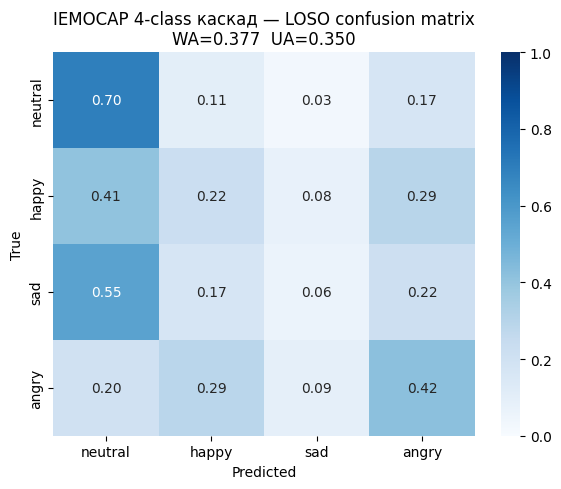

In [22]:
# === Агрегированная confusion matrix ===
yt = np.concatenate([f['y_true'] for f in loso_folds])
pr = np.concatenate([f['y_pred'] for f in loso_folds])
cm  = confusion_matrix(yt, pr, labels=list(range(N_CLS)))
cmn = cm.astype(float) / cm.sum(1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=LABELS_4, yticklabels=LABELS_4,
            vmin=0, vmax=1, cbar=True, ax=ax)
ax.set_title(f'IEMOCAP 4-class каскад — LOSO confusion matrix\n'
             f'WA={accuracy_score(yt, pr):.3f}  UA={balanced_accuracy_score(yt, pr):.3f}')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig(OUT_DIR / 'confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## Заметки и отклонения от плана

- **Каскад.** Аудио-модель (бинарный neutral/non-neutral) → видео-модель (3 класса happy/sad/angry) запускается только на предсказанных non-neutral. Итог: гейт neutral → класс `neutral`; иначе → класс от видео-модели.
- **Предобучение и дообучение (§7–§8).** Обе модели инициализируются весами, предобученными на RAVDESS+CREMA-D, и дообучаются двухэтапно (feature extraction → fine-tuning) отдельно в каждом фолде.
  - *Аудио:* предобученная MelCNN уже бинарная — последний слой не заменяется. Этап 1 — `classifier` (conv-backbone заморожен, BatchNorm в eval). Этап 2 — вся сеть, lr 5e-5.
  - *Видео:* последний слой BiLSTM-головы заменён на случайный 3-выходной. Этап 1 — только новый слой. Этап 2 — вся голова, дифференцированный lr (5e-5 предобученное / 1e-4 новый слой).
- **Аудио — отклонение от §4.** Чтобы предобученная `MelCNN` получала вход из того же распределения, на котором училась, аудио готовится **в точности как при предобучении** (`audio_neutral_check_augmentation`): загрузка + ресемпл 16 кГц, без trim / pre-emphasis / peak-norm из §4 (они меняют спектр и ломают смысл предобученных весов). Волна нативной длины кешируется в `datasets/iemocap_audio_cache_v2/`. log-mel: 64 канала, hop 512, `power_to_db(ref=np.max)`, нормировка глобальными статистиками предобучения; время приводится к 128 кадрам — коротко zero-pad, длинно линейная интерполяция (вся реплика в окне, поздний контент не теряется).
- **Аудио-аугментации (§6).** На лету при обучении аудио-модели: гауссовский шум, сдвиг во времени, time-stretch, pitch-shift. Random gain и инверсия полярности из §6 на log-mel с `ref=np.max` не влияют (инвариантность к масштабу и знаку) — заменены на сдвиг и time-stretch.
- **Видео (§5) — отклонение.** Признаки EmotiEffNet берутся готовыми из кеша `datasets/iemocap_features_cache_v3/` (16 кадров/реплику). Полное переизвлечение видео по §5 (10 fps, 80 кадров, ресайз 224×224, видео-аугментации) потребовало бы многосуточного декодирования видео IEMOCAP и здесь **не выполняется**. Поэтому экстрактор EmotiEffNet **заморожен** (используются кешированные признаки), обучается только BiLSTM-голова; видео-аугментации §5 не применяются.
- **LOSO.** Строго по сессиям, без random-shuffle; val — следующая сессия по циклу. Все seed зафиксированы (§11). Лучшие веса обеих моделей сохраняются по фолдам (`models/{Session}_{gate,video}.pt`).
- **Учёт ошибок гейта (§11).** Ложный non-neutral на истинно-нейтральном примере → видео-модель выдаёт эмоцию → ошибка; ложный neutral на эмоциональном → ошибка. Оба случая попадают в 4-классовые WA/UA/F1 автоматически.
- Главная метрика — **UA (UAR)**. Ориентир для IEMOCAP 4-class LOSO (аудио+видео): UA ≈ 60–72 %.